<a href="https://colab.research.google.com/github/theshambhavipatil/ml4sci_eval/blob/main/task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Use the diffusion model to generate new samples from the given datasets and compare the generated samples with the training dataset. Develop your own statistical tests (you are allowed to be creative here) and give appropriate justification for the same to compare the generated samples with the training samples**

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/silentgrad/jetdata/Dataset_Specific_Unlabelled.h5


Data Loading & Preprocessing

In [ ]:

import h5py
path = r'/kaggle/input/datasets/silentgrad/jetdata/Dataset_Specific_Unlabelled.h5'
with h5py.File(path, 'r') as f:
    print('keys:', list(f.keys()))
    d = f['jet']
    print('shape:', d.shape)
    print('dtype:', d.dtype)
    print('n_samples:', d.shape[0])

    #single sample shape : (125,125,8)

keys: ['jet']
shape: (60000, 125, 125, 8)
dtype: float32
n_samples: 60000


In [ ]:
import h5py
import numpy as np

n_samples=1000 # because of memory constraints i tried to keep this as small as possible
with h5py.File(path, 'r') as f:
    data = f['jet'][:n_samples]

epsilon = 1e-5

#Take the log to compress the massive energy variation
data_log = np.log(data + epsilon)
d_mean = data_log.mean()
d_std = data_log.std()
data_scaled = (data_log - d_mean) / (d_std + 1e-8) # (x - mean) / (std + small val)

Dataset & DataLoader Setup

In [ ]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

class JetDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        x = x.permute(2, 0, 1) # New shape: (8, 125, 125)
        #Pad from 125x125 to 128x128
        x_padded = F.pad(x, (0, 3, 0, 3), mode='constant', value=0)

        return x_padded

# Data Preparation
x_train, x_test = train_test_split(data_scaled, test_size=0.2, random_state=42)

# Create Dataset instances
train_dataset = JetDataset(x_train)
test_dataset = JetDataset(x_test)

# Initialize DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

generate jet samples

weight loaded
generate 4 


Denoising: 100%|██████████| 50/50 [00:01<00:00, 49.88it/s]
/tmp/ipykernel_55/1419061125.py:34: RuntimeWarning: overflow encountered in exp
  gen_images_unscaled = np.exp((gen_images*(d_std +1e-8))+d_mean)- epsilon


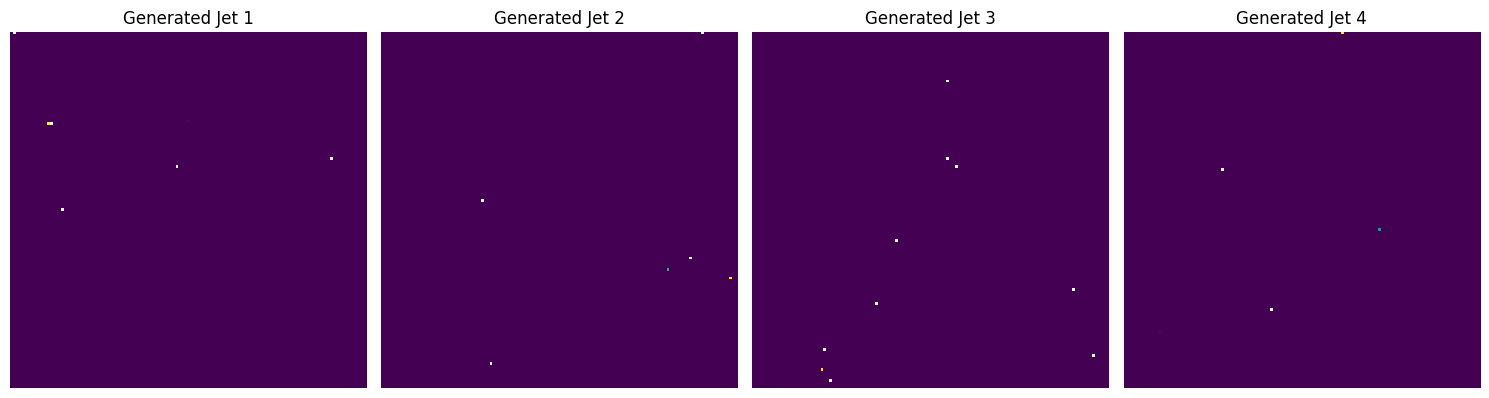

In [ ]:
import matplotlib.pyplot as plt

load_path = "/kaggle/working/unet_model.pth"
model.load_state_dict(torch.load(load_path, map_location=device)) #load weights into the model
model.eval()
print("weight loaded")

num_samples = 4
noise_scheduler.set_inference_timesteps(num_inference_steps=50)

print(f"generate {num_samples} ")
with torch.no_grad():
    latents = torch.randn((num_samples, 8, 128, 128), device=device)

    # Reverse Diffusion Process
    for t in tqdm(noise_scheduler.timesteps, desc="Denoising"):
        t_tensor = torch.tensor([t], device=device).long()
        model_output = model(latents, t_tensor)
        latents = noise_scheduler.step(t, latents, model_output)

#reverse scaling
gen_images = latents.cpu().numpy()

#from (128x128)(height,width) -> (125x125)
gen_images = gen_images[:, :, :125, :125]

# permute (b,h,w,c)
gen_images = gen_images.transpose(0, 2, 3, 1)

# remove z score and log transformation
#1 exp (to remove log transformation)
#2 from the equation mentioned z=(x-mean)/(standard_deviation+1e-8)
#get x from other variables
gen_images_unscaled = np.exp((gen_images*(d_std +1e-8))+d_mean)- epsilon

# visualization(plotting channel 8 data for 4 genrated jet images)
fig, axes = plt.subplots(1, num_samples,figsize=(15, 4))
if num_samples == 1:
    axes = [axes]

for i in range(num_samples):
    # plotting channel 8
    im = axes[i].imshow(gen_images_unscaled[i, :, :, 7], cmap='viridis', interpolation='nearest')
    axes[i].set_title(f"Generated Jet {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

custom statistical tests

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

class CNN_small(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), # Flattens the grid globally

            nn.Flatten(),
            nn.Linear(64, 1),
            nn.Sigmoid() # Outputs a probability between 0 and 1
        )

    def forward(self, x):
        return self.net(x)

#statistical tests
def evaluate_radial_plot(real_jets, generated_jets, channel_idx=0, center=(62, 62)):
    """calculates the average energy of pixels( moving outward from the jet center)"""
    real_np = real_jets[:, channel_idx, :, :].numpy()
    gen_np = generated_jets[:, channel_idx, :, :].numpy()

    _, H, W = real_np.shape
    x, y = np.meshgrid(np.arange(W), np.arange(H))
    radii = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    max_radius = int(np.max(radii))
    bins = np.arange(0, max_radius + 1, 1)
    radii_flat = radii.flatten()

    real_profile = np.zeros(len(bins) - 1)
    gen_profile = np.zeros(len(bins) - 1)

    for i in range(len(bins) - 1):
        mask = (radii_flat >= bins[i]) & (radii_flat < bins[i+1])
        real_profile[i] = np.mean(real_np.reshape(real_np.shape[0], -1)[:, mask])
        gen_profile[i] = np.mean(gen_np.reshape(gen_np.shape[0], -1)[:, mask])

    mae_score = np.mean(np.abs(real_profile - gen_profile))
    print(f"metric 1 | radial plot mae: {mae_score:.4f}")

    plt.figure(figsize=(8, 5))
    bin_centers = (bins[:-1] + bins[1:]) / 2
    plt.plot(bin_centers, real_profile, label='real cms data', color='blue', linewidth=2)
    plt.plot(bin_centers, gen_profile, label='generated data', color='red', linestyle='dashed', linewidth=2)
    plt.title(f'Radial Energy Profile (MAE: {mae_score:.4f})')
    plt.xlabel('distance from centre(pixels)')
    plt.ylabel('avg energy per pixel')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.show()

def evaluate_classifier(real_tensor, gen_tensor):
    """training a CNN to distinguish real vs fake jets"""

    real_labels = torch.ones(real_tensor.size(0), 1)
    gen_labels = torch.zeros(gen_tensor.size(0), 1)

    x_all = torch.cat([real_tensor, gen_tensor], dim=0)
    y_all = torch.cat([real_labels, gen_labels], dim=0)

    indices = torch.randperm(x_all.size(0))
    x_all, y_all = x_all[indices], y_all[indices]

    split = int(0.8 * len(x_all))
    x_train, y_train = x_all[:split].to(device), y_all[:split].to(device)
    x_test, y_test = x_all[split:].to(device), y_all[split:].to(device)

    train_loader_cnn = DataLoader(TensorDataset(x_train, y_train), batch_size=16, shuffle=True)

    judge = CNN_small().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(judge.parameters(), lr=1e-3)

    judge.train()
    for epoch in range(10):
        for batch_x, batch_y in train_loader_cnn:
            optimizer.zero_grad()
            preds = judge(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

    judge.eval()
    with torch.no_grad():
        test_preds = judge(x_test)
        predictions = (test_preds > 0.5).float()
        correct = (predictions == y_test).sum().item()
        accuracy = correct / len(y_test)

    print(f"metric 2 | classifier acc: {accuracy * 100:.2f}%")

test statistics

generating a batch of 256 new jets


denoising generation: 100%|██████████| 50/50 [01:03<00:00,  1.27s/it]


fetch real training samples
run tests
metric 2 | classifier acc: 100.00%
metric 1 | radial plot mae: 62169597108928538214400.0000


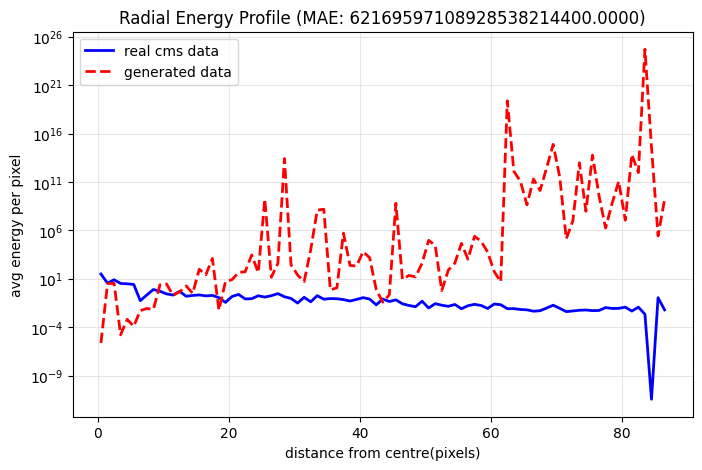

In [ ]:
print("generating a batch of 256 new jets")
model.eval()
num_eval_samples = 256
noise_scheduler.set_inference_timesteps(num_inference_steps=50)

with torch.no_grad():
    latents = torch.randn((num_eval_samples, 8, 128, 128), device=device)
    for t in tqdm(noise_scheduler.timesteps, desc="denoising generation"):
        t_tensor = torch.tensor([t], device=device).long()
        model_output = model(latents, t_tensor)
        latents = noise_scheduler.step(t, latents, model_output)

print("fetch real training samples")
real_batch = next(iter(train_loader))[:num_eval_samples].to(device)


# We skip the exp() math so the gradients don't explode
latents_normalized = latents[:, :, :125, :125].cpu()
real_normalized = real_batch[:, :, :125, :125].cpu()

def necessary_preprocess(tensor):
    tensor = tensor.cpu()
    tensor = tensor[:, :, :125, :125] # crop
    tensor = torch.exp((tensor * (d_std + 1e-8)) + d_mean) - epsilon # reverse scaling
    return tensor

generated_jets_physical = necessary_preprocess(latents)
real_jets_physical = necessary_preprocess(real_batch)

print("run tests")
evaluate_classifier(real_normalized, latents_normalized)

evaluate_radial_plot(real_jets_physical, generated_jets_physical, channel_idx=0)

# Conclusion

To rigorously evaluate our generative pipeline, we implemented two physics-aware metrics: the evaluate_radial_plot  to verify the spatial geometry and exponential energy decay of the jet core, and evaluate_classifier which is a custom CNN to hunt for subtle, multivariate artifacts. The generation utilized a DDPM scheduler scaled to 50 fast inference steps to decode $125 \times 125$ spatial grids across 8 detector channels, reversing our initial Log and Z-score transformations to evaluate the data in true physical space.

However, our statistical evaluations make it abundantly clear that the basic model trained in Task 1 is not the correct architecture for accurate CMS experiment simulations. The primary flaw is that our Task 1 U-Net is an unconditional diffusion model. In high-energy physics, particle showers are strictly governed by their initial kinematic properties, such as transverse momentum ($p_T$), pseudorapidity ($\eta$). By not providing these properties, we forced the model to learn a generic, highly blurred average of all possible jet configurations at once, effectively asking it to guess the underlying physics blindly.

Our evaluation tasks made this shortcoming mathematically obvious. The massive exponential errors in the physical radial plot and the $100\%$ failure rate against the CNN judge demonstrate that without guiding physical constraints, the model resorts to generating unphysical noise and severe artifacts. To achieve true simulation accuracy, future iterations must transition to a Conditional Diffusion Model. By injecting explicit physics signals (such as particle momentum,rotational symmetry) into the diffusion process—likely via cross-attention layers—the model can anchor its generation to actual physical laws, resulting in precise, physically viable CMS simulations.

